OR GATE SINGLE PERCEPTRON - HARD-CODED WEIGHTS
 Weights: W1=1.0, W2=1.0
 Bias: b=-0.5
 Equation: 1.0x1 + 1.0x2 + -0.5 > 0

PREDICTIONS
[0, 0] → Linear:  -0.5 → Pred: 0 | Actual: 0
[0, 1] → Linear:   0.5 → Pred: 1 | Actual: 1
[1, 0] → Linear:   0.5 → Pred: 1 | Actual: 1
[1, 1] → Linear:   1.5 → Pred: 1 | Actual: 1


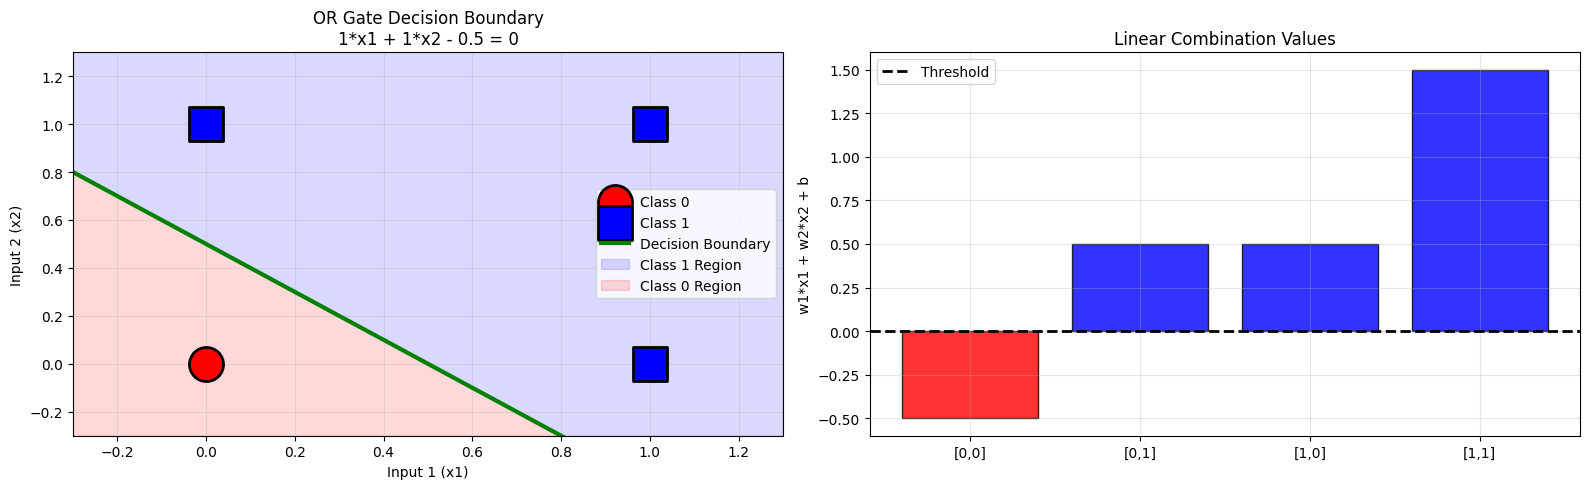


VERIFICATION RESULTS:
 Decision boundary (solved for x2): x2 = (-1.0*x1 - (-0.5)) / 1.0
Linear values for each input:
 [0, 0]: 1*0 + 1*0 - 0.5 = -0.5
  -> Class 0 (<=0)
 [0, 1]: 1*0 + 1*1 - 0.5 = 0.5
  -> Class 1 (>0)
 [1, 0]: 1*1 + 1*0 - 0.5 = 0.5
  -> Class 1 (>0)
 [1, 1]: 1*1 + 1*1 - 0.5 = 1.5
  -> Class 1 (>0)

Point positions relative to boundary:
 [0, 0]: -0.500 → Below (Class 0)
 [0, 1]: 0.500 → Above (Class 1)
 [1, 0]: 0.500 → Above (Class 1)
 [1, 1]: 1.500 → Above (Class 1)


In [ ]:
#OR GATE WITH HARD CODED WEIGHT
import numpy as np
import matplotlib.pyplot as plt

# Data for OR gate
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [1]])

print("OR GATE SINGLE PERCEPTRON - HARD-CODED WEIGHTS")
print("=" * 60)

# Weights and bias (hard-coded for OR)
weights = np.array([[1.0], [1.0]])
bias = np.array([[-0.5]])

print(f" Weights: W1={weights[0,0]:.1f}, W2={weights[1,0]:.1f}")
print(f" Bias: b={bias[0,0]:.1f}")
print(f" Equation: {weights[0,0]:.1f}x1 + {weights[1,0]:.1f}x2 + {bias[0,0]:.1f} > 0")

def step_function(x):
    return 1 if x > 0 else 0

def perceptron_predict(X, weights, bias):
    linear = np.dot(X, weights) + bias
    return (linear > 0).astype(int)

print("\nPREDICTIONS")
linear_values = np.dot(X, weights) + bias
predictions = perceptron_predict(X, weights, bias)

for i in range(len(X)):
    linear_val = linear_values[i, 0]
    pred = predictions[i, 0]
    actual = y[i, 0]
    print(f"[{X[i,0]:.0f}, {X[i,1]:.0f}] → Linear: {linear_val:5.1f} → Pred: {int(pred)} | Actual: {int(actual)}")

# Plot decision boundary and points
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[y.flatten() == 0, 0], X[y.flatten() == 0, 1],
            s=600, marker='o', edgecolors='black', linewidth=2, label='Class 0', zorder=3, color='red')
plt.scatter(X[y.flatten() == 1, 0], X[y.flatten() == 1, 1],
            s=600, marker='s', edgecolors='black', linewidth=2, label='Class 1', zorder=4, color='blue')

x1_range = np.linspace(-0.3, 1.3, 200)
w1, w2, b = weights[0,0], weights[1,0], bias[0,0]
# decision boundary: w1*x1 + w2*x2 + b = 0  -> x2 = (-w1*x1 - b) / w2
x2_boundary = (-w1 * x1_range - b) / w2

plt.plot(x1_range, x2_boundary, 'g-', linewidth=3, label='Decision Boundary', zorder=2)
plt.fill_between(x1_range, x2_boundary, 1.3, alpha=0.15, color='blue', label='Class 1 Region')
plt.fill_between(x1_range, -0.3, x2_boundary, alpha=0.15, color='red', label='Class 0 Region')

plt.xlim(-0.3, 1.3)
plt.ylim(-0.3, 1.3)
plt.xlabel('Input 1 (x1)')
plt.ylabel('Input 2 (x2)')
plt.title('OR Gate Decision Boundary\n1*x1 + 1*x2 - 0.5 = 0')
plt.grid(True, alpha=0.3)
plt.legend()

# Bar plot of linear values
plt.subplot(1, 2, 2)
samples = ['[0,0]', '[0,1]', '[1,0]', '[1,1]']
linear_vals = linear_values.flatten()
colors = ['red' if y[i,0] == 0 else 'blue' for i in range(len(y))]

plt.bar(samples, linear_vals, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
plt.axhline(y=0, color='black', linestyle='--', linewidth=2, label='Threshold')
plt.ylabel('w1*x1 + w2*x2 + b')
plt.title('Linear Combination Values')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Verification prints
print("\nVERIFICATION RESULTS:")
print(f" Decision boundary (solved for x2): x2 = (-{w1:.1f}*x1 - ({b:.1f})) / {w2:.1f}")
print("Linear values for each input:")
for i in range(4):
    z = w1 * X[i,0] + w2 * X[i,1] + b
    print(f" [{X[i,0]:.0f}, {X[i,1]:.0f}]: 1*{X[i,0]:.0f} + 1*{X[i,1]:.0f} - 0.5 = {z:.1f}")
    print(f"  -> {'Class 1 (>0)' if z > 0 else 'Class 0 (<=0)'}")

print("\nPoint positions relative to boundary:")
for i in range(len(X)):
    point_value = w1 * X[i,0] + w2 * X[i,1] + b
    side = "Above (Class 1)" if point_value > 0 else "Below (Class 0)"
    print(f" [{X[i,0]:.0f}, {X[i,1]:.0f}]: {point_value:.3f} → {side}")
